In [2]:
import pandas as pd, numpy as np
df = pd.read_csv(r"C:\Telco\data\raw\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.shape, df.dtypes, df.head()
df.isna().sum()
df['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [3]:
df.shape

(7043, 21)

In [4]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [5]:
  df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
  df['TotalCharges'] = df['TotalCharges'].fillna(0)   # or drop these 11 rows

In [6]:
df.shape

(7043, 21)

In [7]:
df = df.drop(columns='customerID')
df['Churn'] = df['Churn'].map({'Yes':1,'No':0})
df = df.replace({'No internet service':'No','No phone service':'No'})

For each feature, compute the churn rate per category and compare it with the overall rate (~26.5%):

In [8]:
for col in df.select_dtypes('object'):
    print(df.groupby(col)['Churn'].mean().sort_values(ascending=False), "\n")

C:\Users\deepa\AppData\Local\Temp\ipykernel_1520\1442151082.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes('object'):


gender
Female    0.269209
Male      0.261603
Name: Churn, dtype: float64 

Partner
No     0.329580
Yes    0.196649
Name: Churn, dtype: float64 

Dependents
No     0.312791
Yes    0.154502
Name: Churn, dtype: float64 

PhoneService
Yes    0.267096
No     0.249267
Name: Churn, dtype: float64 

MultipleLines
Yes    0.286099
No     0.250246
Name: Churn, dtype: float64 

InternetService
Fiber optic    0.418928
DSL            0.189591
No             0.074050
Name: Churn, dtype: float64 

OnlineSecurity
No     0.313296
Yes    0.146112
Name: Churn, dtype: float64 

OnlineBackup
No     0.291721
Yes    0.215315
Name: Churn, dtype: float64 

DeviceProtection
No     0.286518
Yes    0.225021
Name: Churn, dtype: float64 

TechSupport
No     0.311862
Yes    0.151663
Name: Churn, dtype: float64 

StreamingTV
Yes    0.300702
No     0.243312
Name: Churn, dtype: float64 

StreamingMovies
Yes    0.299414
No     0.243795
Name: Churn, dtype: float64 

Contract
Month-to-month    0.427097
One year          0.

In [9]:
%pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


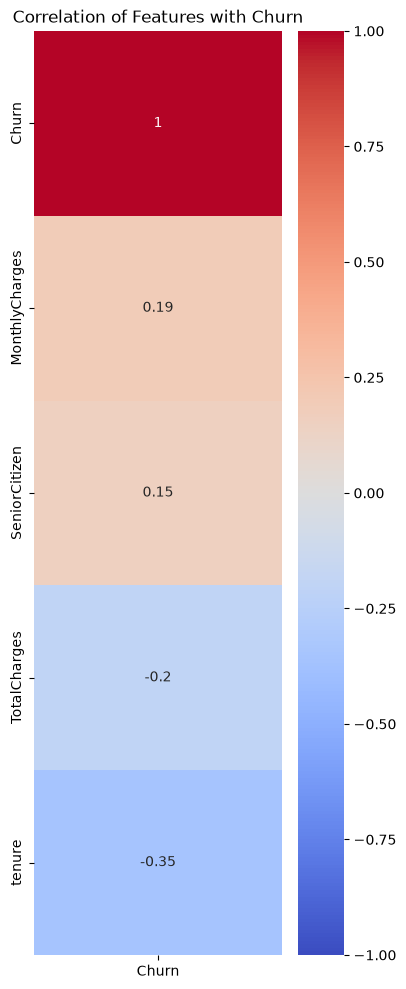

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute correlation matrix only for numeric columns
corr_matrix = df.corr(numeric_only=True)

# Focus on correlation with Churn
churn_corr = corr_matrix[['Churn']].sort_values(
    by='Churn',
    ascending=False
)

# Plot heatmap
plt.figure(figsize=(4, 12))
sns.heatmap(
    churn_corr,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)

plt.title('Correlation of Features with Churn')
plt.show()

In [11]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# Make sure Churn is 0/1
if df['Churn'].dtype == 'object':
    df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2 = chi2_contingency(table)[0]
    n = table.values.sum()
    r, k = table.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

rows = []
for col in df.select_dtypes('object').columns:
    if col == 'customerID':          # skip ID columns
        continue
    rates = df.groupby(col)['Churn'].mean()
    rows.append({
        'feature': col,
        'cramers_v': cramers_v(df[col], df['Churn']),
        'highest_churn_category': rates.idxmax(),
        'highest_churn_rate': rates.max(),
        'lowest_churn_category': rates.idxmin(),
        'lowest_churn_rate': rates.min(),
        'spread': rates.max() - rates.min(),
    })

ranking = pd.DataFrame(rows).sort_values('cramers_v', ascending=False).reset_index(drop=True)
ranking.round(3)

C:\Users\deepa\AppData\Local\Temp\ipykernel_1520\3172504497.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes('object').columns:


,feature,cramers_v,highest_churn_category,highest_churn_rate,lowest_churn_category,lowest_churn_rate,spread
0,Contract,0.410,Month-to-month,0.427,Two year,0.028,0.399
1,InternetService,0.322,Fiber optic,0.419,No,0.074,0.345
2,PaymentMethod,0.303,Electronic check,0.453,Credit card (automatic),0.152,0.300
3,PaperlessBilling,0.191,Yes,0.336,No,0.163,0.172
4,OnlineSecurity,0.171,No,0.313,Yes,0.146,0.167
5,TechSupport,0.164,No,0.312,Yes,0.152,0.160
6,Dependents,0.164,No,0.313,Yes,0.155,0.158
7,Partner,0.150,No,0.330,Yes,0.197,0.133
8,OnlineBackup,0.082,No,0.292,Yes,0.215,0.076
9,DeviceProtection,0.066,No,0.287,Yes,0.225,0.061


In [13]:
# Make sure numeric columns are numeric
df['MonthlyCharges'] = pd.to_numeric(df['MonthlyCharges'], errors='coerce')
df['tenure'] = pd.to_numeric(df['tenure'], errors='coerce')

profile = df.groupby('InternetService').agg(
    customers=('Churn', 'size'),
    churn_rate=('Churn', 'mean'),
    avg_tenure=('tenure', 'mean'),
    avg_monthly=('MonthlyCharges', 'mean'),
)
profile['pct_month_to_month'] = df.groupby('InternetService')['Contract'].apply(lambda s: (s == 'Month-to-month').mean())
profile['pct_electronic_check'] = df.groupby('InternetService')['PaymentMethod'].apply(lambda s: (s == 'Electronic check').mean())
profile.round(3)

,customers,churn_rate,avg_tenure,avg_monthly,pct_month_to_month,pct_electronic_check
InternetService,,,,,,
DSL,2421,0.190,32.822,58.102,0.505,0.268
Fiber optic,3096,0.419,32.918,91.500,0.687,0.515
No,1526,0.074,30.547,21.079,0.343,0.080


In [14]:
fiber = df[df['InternetService'] == 'Fiber optic']
rows = []
for col in fiber.select_dtypes('object').columns:
    if col in ['customerID', 'InternetService']:
        continue
    g = fiber.groupby(col)['Churn'].agg(['mean', 'count'])
    for cat, r in g.iterrows():
        rows.append({'feature': col, 'category': cat,
                     'churn_rate': r['mean'], 'customers': int(r['count'])})

fiber_view = pd.DataFrame(rows)
fiber_view['diff_from_fiber_avg'] = fiber_view['churn_rate'] - fiber['Churn'].mean()
fiber_view.reindex(fiber_view['diff_from_fiber_avg'].abs().sort_values(ascending=False).index).round(3).head(15)

C:\Users\deepa\AppData\Local\Temp\ipykernel_1520\2237374115.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in fiber.select_dtypes('object').columns:


,feature,category,churn_rate,customers,diff_from_fiber_avg
23,Contract,Two year,0.072,429,-0.347
22,Contract,One year,0.193,539,-0.226
10,OnlineSecurity,Yes,0.218,839,-0.201
16,TechSupport,Yes,0.226,866,-0.193
27,PaymentMethod,Credit card (automatic),0.253,597,-0.166
26,PaymentMethod,Bank transfer (automatic),0.289,646,-0.129
21,Contract,Month-to-month,0.546,2128,0.127
12,OnlineBackup,Yes,0.303,1343,-0.116
5,Dependents,Yes,0.305,662,-0.114
28,PaymentMethod,Electronic check,0.532,1595,0.113


In [15]:
pd.pivot_table(df[df['InternetService'] != 'No'], values='Churn',
               index='Contract', columns='InternetService', aggfunc='mean').round(3)

InternetService,DSL,Fiber optic
Contract,,
Month-to-month,0.322,0.546
One year,0.093,0.193
Two year,0.019,0.072


In [16]:
addons = ['OnlineSecurity', 'TechSupport', 'OnlineBackup', 'DeviceProtection']
for a in addons:
    print(a)
    print(fiber.groupby(a)['Churn'].agg(['mean', 'count']).round(3), "\n")

OnlineSecurity
                 mean  count
OnlineSecurity              
No              0.494   2257
Yes             0.218    839 

TechSupport
              mean  count
TechSupport              
No           0.494   2230
Yes          0.226    866 

OnlineBackup
               mean  count
OnlineBackup              
No            0.508   1753
Yes           0.303   1343 

DeviceProtection
                   mean  count
DeviceProtection              
No                0.500   1739
Yes               0.315   1357 



In [18]:
pd.pivot_table(fiber, values='Churn', index='Contract',
               columns='TechSupport', aggfunc=['mean', 'count']).round(3)

mean        count     
TechSupport        No    Yes    No  Yes
Contract                               
Month-to-month  0.575  0.389  1796  332
One year        0.185  0.204   313  226
Two year        0.083  0.068   121  308

In [19]:
pd.pivot_table(fiber, values='Churn', index='Contract',
               columns='OnlineSecurity', aggfunc=['mean', 'count']).round(3)

mean        count     
OnlineSecurity     No    Yes    No  Yes
Contract                               
Month-to-month  0.581  0.370  1774  354
One year        0.208  0.171   317  222
Two year        0.102  0.053   166  263

In [20]:
df['tenure'] = pd.to_numeric(df['tenure'], errors='coerce')

prof = df.groupby('PaymentMethod').agg(
    customers=('Churn', 'size'),
    churn_rate=('Churn', 'mean'),
    avg_tenure=('tenure', 'mean'),
    median_tenure=('tenure', 'median'),
)
prof['pct_month_to_month'] = df.groupby('PaymentMethod')['Contract'].apply(lambda s: (s == 'Month-to-month').mean())
prof.round(3).sort_values('churn_rate', ascending=False)


,customers,churn_rate,avg_tenure,median_tenure,pct_month_to_month
PaymentMethod,,,,,
Electronic check,2365,0.453,25.175,18.0,0.782
Mailed check,1612,0.191,21.830,15.0,0.554
Bank transfer (automatic),1544,0.167,43.657,48.0,0.381
Credit card (automatic),1522,0.152,43.269,47.0,0.357


In [21]:
df['tenure_bucket'] = pd.cut(df['tenure'], [0, 6, 12, 24, 48, 72], include_lowest=True)

pd.pivot_table(df, values='Churn', index='tenure_bucket',
               columns='PaymentMethod', aggfunc='mean', observed=True).round(3)

PaymentMethod,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
tenure_bucket,,,,
"(-0.001, 6.0]",0.553,0.412,0.672,0.375
"(6.0, 12.0]",0.348,0.287,0.497,0.201
"(12.0, 24.0]",0.220,0.232,0.484,0.101
"(24.0, 48.0]",0.160,0.158,0.338,0.091
"(48.0, 72.0]",0.073,0.066,0.216,0.012


In [22]:
pd.pivot_table(df, values='Churn', index='tenure_bucket',
               columns='PaymentMethod', aggfunc='count', observed=True)

PaymentMethod,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
tenure_bucket,,,,
"(-0.001, 6.0]",114,131,686,550
"(6.0, 12.0]",115,94,292,204
"(12.0, 24.0]",177,181,380,286
"(24.0, 48.0]",376,379,520,319
"(48.0, 72.0]",762,737,487,253


In [23]:
pd.crosstab(df['tenure_bucket'], df['PaymentMethod'], normalize='index').round(3)

PaymentMethod,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
tenure_bucket,,,,
"(-0.001, 6.0]",0.077,0.088,0.463,0.371
"(6.0, 12.0]",0.163,0.133,0.414,0.289
"(12.0, 24.0]",0.173,0.177,0.371,0.279
"(24.0, 48.0]",0.236,0.238,0.326,0.200
"(48.0, 72.0]",0.340,0.329,0.218,0.113


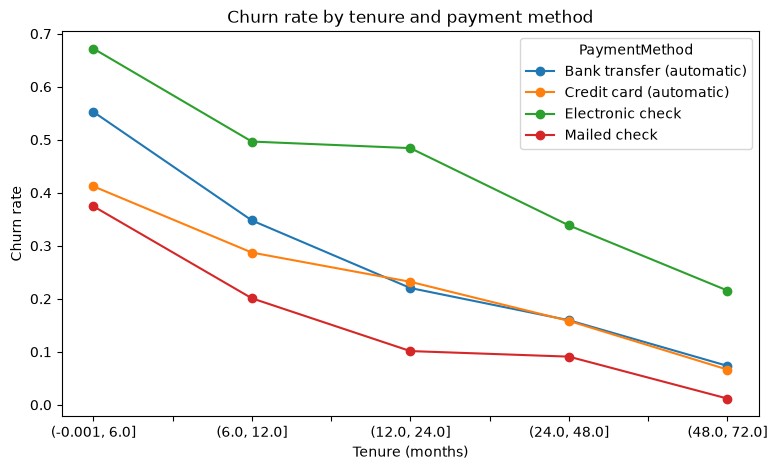

In [24]:
import matplotlib.pyplot as plt

pivot = pd.pivot_table(df, values='Churn', index='tenure_bucket',
                       columns='PaymentMethod', aggfunc='mean', observed=True)
pivot.plot(marker='o', figsize=(9, 5), title='Churn rate by tenure and payment method')
plt.ylabel('Churn rate')
plt.xlabel('Tenure (months)')
plt.show()

In [25]:
pd.pivot_table(df, values='Churn', index='Contract',
               columns='PaymentMethod', aggfunc=['mean', 'count'], observed=True).round(3)

mean                          \
PaymentMethod  Bank transfer (automatic) Credit card (automatic)   
Contract                                                           
Month-to-month                     0.341                   0.328   
One year                           0.097                   0.103   
Two year                           0.034                   0.022   

                                                                 count  \
PaymentMethod  Electronic check Mailed check Bank transfer (automatic)   
Contract                                                                 
Month-to-month            0.537        0.316                       589   
One year                  0.184        0.068                       391   
Two year                  0.077        0.008                       564   

                                                                      
PaymentMethod  Credit card (automatic) Electronic check Mailed check  
Contract                                                              
Month-to-month                     543             1850          893  
One year                           398              347          337  
Two year                           581              168          382

In [28]:
%pip install statsmodels

  Using cached statsmodels-0.15.0-cp313-cp313-win_amd64.whl.metadata (9.6 kB)
  Using cached patsy-1.0.3-py2.py3-none-any.whl.metadata (3.7 kB)
  Using cached formulaic-1.2.2-py3-none-any.whl.metadata (7.0 kB)
  Using cached interface_meta-2.0.1-py3-none-any.whl.metadata (6.4 kB)
  Using cached wrapt-2.5.0-cp313-cp313-win_amd64.whl.metadata (7.7 kB)
Using cached statsmodels-0.15.0-cp313-cp313-win_amd64.whl (11.3 MB)
Using cached formulaic-1.2.2-py3-none-any.whl (118 kB)
Using cached interface_meta-2.0.1-py3-none-any.whl (15 kB)
Using cached patsy-1.0.3-py2.py3-none-any.whl (233 kB)
Using cached wrapt-2.5.0-cp313-cp313-win_amd64.whl (105 kB)

   ---------------------------------------- 0/5 [wrapt]
   ---------------------------------------- 0/5 [wrapt]
   -------- ------------------------------- 1/5 [patsy]
   -------- ------------------------------- 1/5 [patsy]
   -------- ------------------------------- 1/5 [patsy]
   -------- ------------------------------- 1/5 [patsy]
   -------- --

In [26]:
import statsmodels.formula.api as smf
m = smf.logit("Churn ~ C(PaymentMethod, Treatment('Credit card (automatic)')) + tenure + C(Contract)", data=df).fit()
print(np.exp(m.params).round(2))


ModuleNotFoundError: No module named 'statsmodels'